In [2]:
# Load libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys

%load_ext autoreload
%autoreload 2

# Import load_csv
sys.path.append("project")
from helpers import *

In [3]:
# Dataset shape without using pandas
x_train, x_test, y_train, train_ids, test_ids = load_csv_data('data/dataset')

print("Train set shape : ", x_train.shape)
print("Test set shape : ", x_test.shape)
print(test_ids)

Train set shape :  (328135, 320)
Test set shape :  (109379, 320)
[44 27 35 ...  9 15 45]


In [4]:
# Number of lines that contain NaN values in train set
count_rows_with_nan = np.sum(np.isnan(x_train).any(axis=1))
print("Number of rows containing at least one NaN in train set:", count_rows_with_nan)

# Number of columns that contain NaN values in train set
count_columns_with_nan = np.sum(np.isnan(x_train).any(axis=0))
print("Number of columns containing at least one NaN in train set:", count_columns_with_nan)

# Number of lines that contain NaN values in test set
count_rows_with_nan = np.sum(np.isnan(x_test).any(axis=1))
print("Number of rows containing at least one NaN in test set:", count_rows_with_nan)

# Number of columns that contain NaN values in test set
count_columns_with_nan = np.sum(np.isnan(x_test).any(axis=0))
print("Number of columns containing at least one NaN in test set:", count_columns_with_nan)

Number of rows containing at least one NaN in train set: 328135
Number of columns containing at least one NaN in train set: 239
Number of rows containing at least one NaN in test set: 109379
Number of columns containing at least one NaN in test set: 232


In [7]:
def show_NaN_cols(x, x_label):
    """
    Plot the percentage of columns of x that contains a specific percentage of NaN values

    Args:
        x (np.array): input data to analyze  
        x_label: string that describes the dataset x
    """
    
    percentiles = list(range(0, 101, 5))
    # Calcul du pourcentage des colonnes ayant un pourcentage de NaN entre x% et (x+5)%
    percentage_columns_with_percentile_nans = [
        (np.isnan(x).sum(axis=0)[
            (np.isnan(x).sum(axis=0) >= x.shape[0]*p/100) &
            (np.isnan(x).sum(axis=0) < x.shape[0]*(p+5)/100)
        ].shape[0] / x.shape[1]) * 100 for p in percentiles[:-1]  # Exclude the last percentile (100%)
    ]

    # Labels for the x-axis
    percentile_labels = [f'{p}-{p+5}%' for p in percentiles[:-1]]

    # Affichage du graphique
    plt.figure(figsize=(15, 6))
    plt.bar(percentile_labels, percentage_columns_with_percentile_nans)

    plt.title('Percentage of columns with NaN values in intervals of 5% in the {}'.format(x_label))
    plt.xlabel('Percentage Range of NaN')
    plt.ylabel('Percentage of columns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

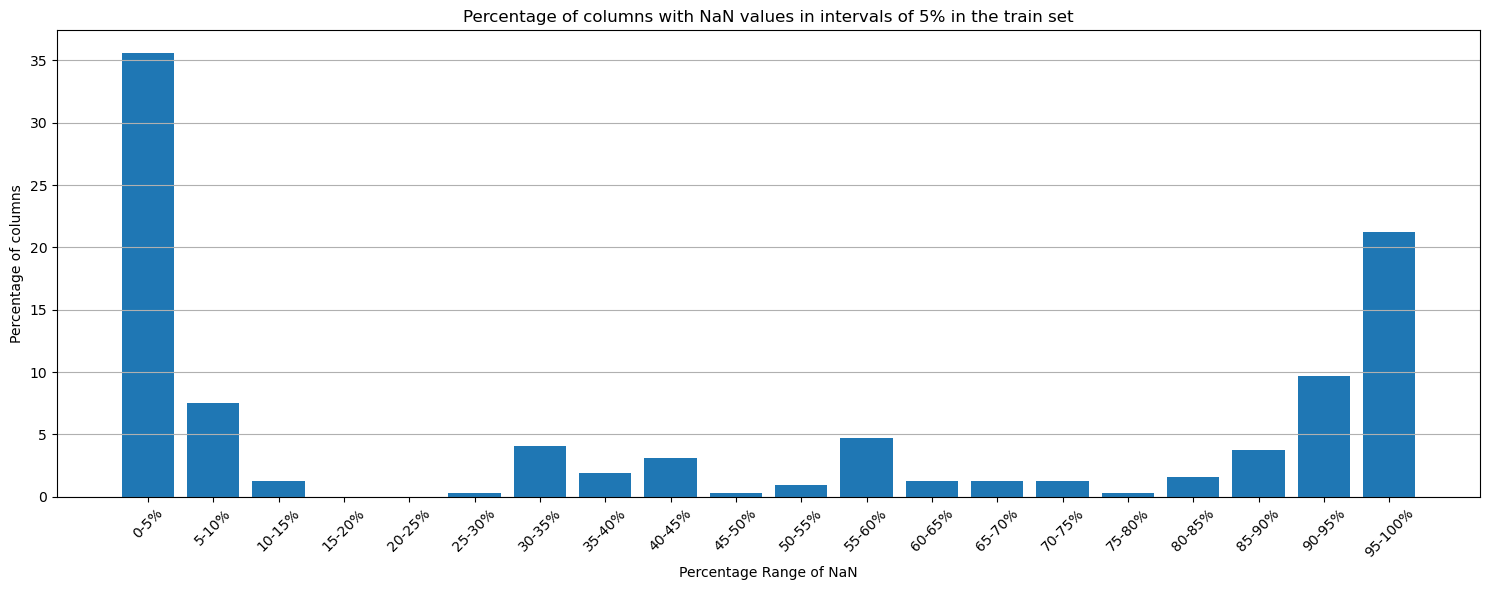

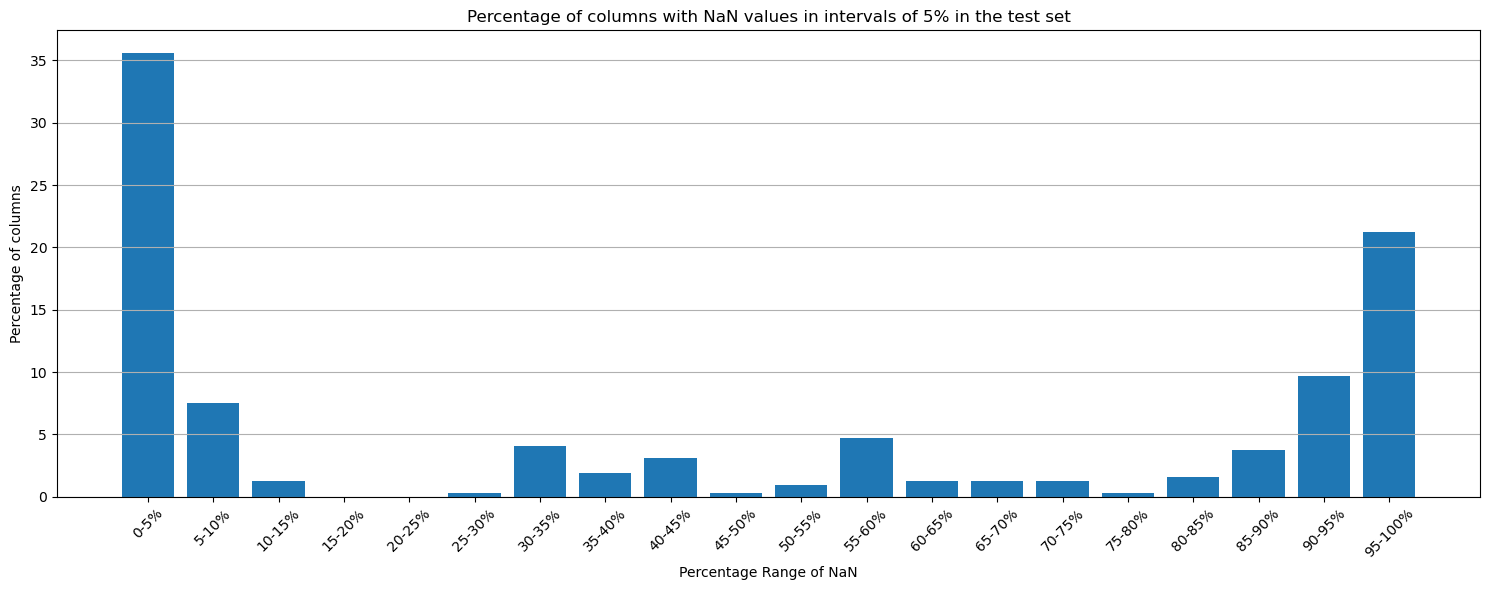

In [8]:
#Analyze the input
show_NaN_cols(x_train, "train set")
show_NaN_cols(x_test, "test set")

In [9]:
def filter_cols(x, threshold):
    """
    Add the mean of the columns with NaN and return indices of the columns to exclude in the regression including
    those were the standard deviation is equal to 0.
        
    Args:
        x (np.array): data
        threshold (int): % of NaN values that should contain a column of x
        
    Returns:
        f_x: data with NaN values replaces by zeroes
        rem_cols (np.array): list of indices of columns that contains more than threshold% of NaN values and that
            doesn't contain any 0 standard deviation
    """
    
    f_x = x
    error_matrix = np.isnan(x)
    
    #Identify indices of the columns with more than threshold percentage of NaN values
    nan_ = (np.sum(error_matrix, axis=0) / x.shape[0]) * 100
    rem_cols_NaN = np.where(nan_ > threshold)[0]
    
    #Replace NaN values with the mean of it's columns
    column_means = np.nanmean(f_x, axis=0)
    f_x[error_matrix] = np.take(column_means, np.where(error_matrix)[1])
    
    #Identify columns with 0 standard deviation
    std_x = np.std(f_x, axis=0)
    rem_cols_std = np.where(std_x == 0)[0]
    
    #Final array with indices of the columns to exclude in the classification
    rem_cols = np.unique(np.concatenate((rem_cols_NaN, rem_cols_std)))
    
    return f_x, rem_cols

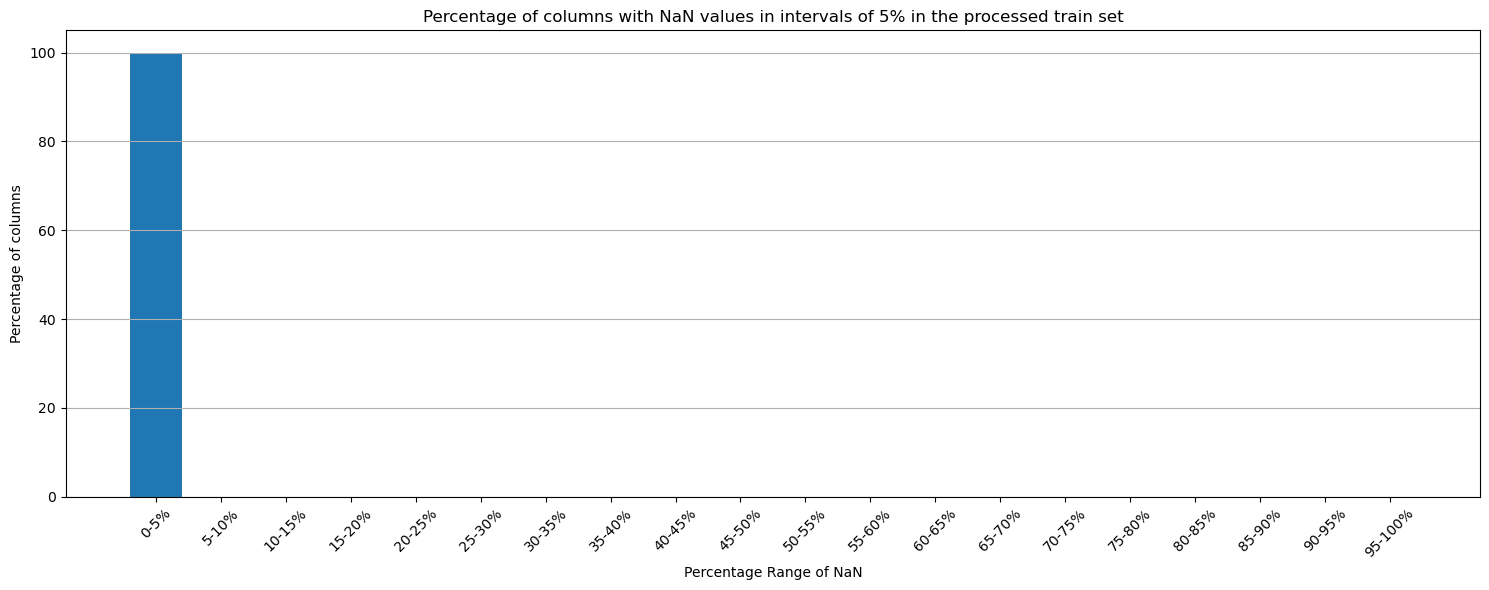

In [10]:
f_x, cols_excluded = filter_cols(x_train,50)
show_NaN_cols(f_x, "processed train set")

In [20]:
def standardize_std(x):
    """
    Standardize the columns of x, might do some other processing after
        
    Args:
        x (np.array): data
        
    Returns:
        s_x: standardized matrix 
    """
    s_x, mean_x, std_x  = standardize(x)
    
    return s_x, mean_x, std_x

In [21]:
def remove_feature(x, ft):
    """
    Remove features given our model.
    
    Args:
        x (np.array): data
        ft (np.array): indcides of the array of features to remove in x
    Returns:
        f_x: filtered matrix
    """
    

In [24]:
T_x, mean_x, std_x = standardize_std(f_x)

[[1.10000000e+01 1.11620150e+07 1.10000000e+01 ... 2.28990981e+00
  2.40679360e+00 2.00000000e+00]
 [1.20000000e+01 1.21520150e+07 1.20000000e+01 ... 2.28990981e+00
  2.40679360e+00 1.96667511e+00]
 [1.00000000e+01 1.02020150e+07 1.00000000e+01 ... 1.00000000e+00
  2.00000000e+00 2.00000000e+00]
 ...
 [1.00000000e+01 1.02020150e+07 1.00000000e+01 ... 2.00000000e+00
  2.00000000e+00 2.00000000e+00]
 [1.20000000e+01 1.23020150e+07 1.20000000e+01 ... 2.28990981e+00
  2.40679360e+00 2.00000000e+00]
 [9.00000000e+00 9.12201500e+06 9.00000000e+00 ... 2.28990981e+00
  2.40679360e+00 2.00000000e+00]]


In [29]:
# Print the mean and the standard deviation of T_x
print("Mean of T_x : ", np.mean(T_x))
print("Standard deviation of T_x : ", np.std(T_x))

Mean of T_x :  7.109951008488362e-17
Standard deviation of T_x :  0.9999999999999977


In [39]:
# Remove the columns whose index are in cols_excluded

T_x_filtered = np.delete(f_x, cols_excluded, axis=0)
T_x_filtered, m_x_filtered, std_x_filtered = standardize_std(T_x_filtered)

[[1.10000000e+01 1.11620150e+07 1.10000000e+01 ... 2.28990981e+00
  2.40679360e+00 2.00000000e+00]
 [1.20000000e+01 1.21520150e+07 1.20000000e+01 ... 2.28990981e+00
  2.40679360e+00 1.96667511e+00]
 [1.00000000e+01 1.02020150e+07 1.00000000e+01 ... 1.00000000e+00
  2.00000000e+00 2.00000000e+00]
 ...
 [1.00000000e+01 1.02020150e+07 1.00000000e+01 ... 2.00000000e+00
  2.00000000e+00 2.00000000e+00]
 [1.20000000e+01 1.23020150e+07 1.20000000e+01 ... 2.28990981e+00
  2.40679360e+00 2.00000000e+00]
 [9.00000000e+00 9.12201500e+06 9.00000000e+00 ... 2.28990981e+00
  2.40679360e+00 2.00000000e+00]]


In [40]:
print("Mean of T_x_filtered : ", np.mean(T_x_filtered))
print("Standard deviation of T_x_filtered : ", np.std(T_x_filtered))
print(T_x_filtered.shape)

Mean of T_x_filtered :  1.3332338694579255e-16
Standard deviation of T_x_filtered :  0.9999999999999969
(327986, 320)


In [49]:
# export the filtered data to csv
np.savetxt("data/filtered_dataset.csv", T_x_filtered, delimiter=",")

## PCA

In [41]:
covariance_matrix = np.cov(T_x_filtered, rowvar=False, dtype=np.float64)

eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [42]:
# check if the eingenvalues are complex

if np.any(np.iscomplex(eigenvalues)):
    print("Eigenvalues are complex")
else:
    print("Eigenvalues are real")

Eigenvalues are complex


In [43]:
# Select the number of principal components (e.g., first two)
num_components = 2
selected_eigenvectors = eigenvectors[:, :num_components]


In [44]:
reduced_data = np.dot(T_x_filtered, selected_eigenvectors)


/Users/tatianahominal/anaconda3/lib/python3.11/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


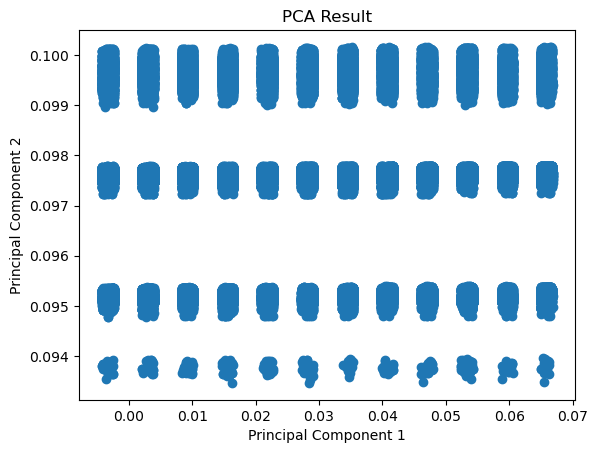

In [45]:
plt.scatter(reduced_data[:, 0], reduced_data[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()

/Users/tatianahominal/anaconda3/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


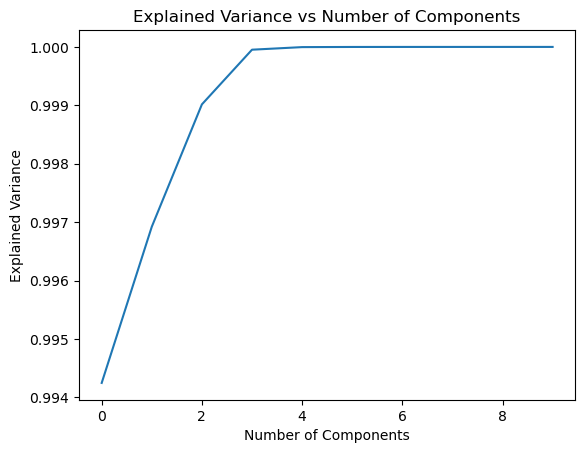

In [46]:
# Plot explained variance 
plt.plot(np.cumsum(eigenvalues[0:10]) / np.sum(eigenvalues))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.show()


In [47]:
eigenvalues[0] / np.sum(eigenvalues)


(0.9942471492709961-7.173018420214762e-43j)

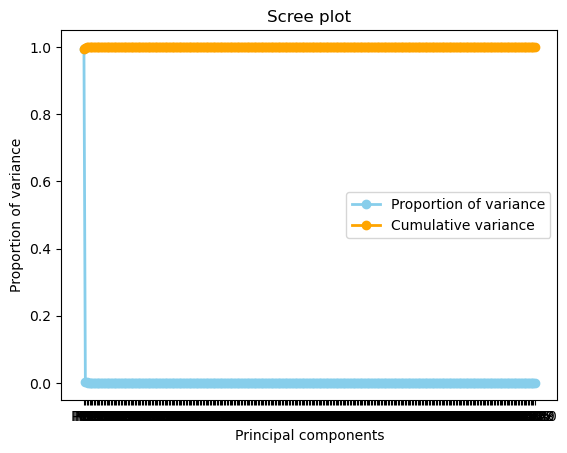

In [48]:
#1. Calculate the proportion of variance explained by each feature
sum_eigenvalues = np.sum(eigenvalues)

prop_var = [i/sum_eigenvalues for i in eigenvalues]

#2. Calculate the cumulative variance
cum_var = [np.sum(prop_var[:i+1]) for i in range(len(prop_var))]


#3. Plot the results

x_labels = ['PC{}'.format(i+1) for i in range(len(prop_var))]

plt.plot(x_labels, prop_var, marker='o', markersize=6, color='skyblue', linewidth=2, label='Proportion of variance')
plt.plot(x_labels, cum_var, marker='o', color='orange', linewidth=2, label="Cumulative variance")
plt.legend()
plt.title('Scree plot')
plt.xlabel('Principal components')
plt.ylabel('Proportion of variance')
plt.show()